# Lab: K-Means Clustering

*In this lab, we will build a **K-Means Clustering** model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

> ### 📝 1. Business Understanding Report (Summary)
> - **Business Context:** "ShopSmart Mall" is a regional shopping center that has been collecting customer data through its loyalty program, including demographic information and purchasing behaviour metrics. The mall's management currently treats all customers the same, offering identical promotions, communications, and services to everyone. However, they suspect that their customer base is diverse, with different groups having distinct shopping patterns, spending capacities, and preferences. 
> - **Business Problem:** The marketing and operations teams lack a data-driven understanding of their customer base's natural groupings. Without this segmentation, they cannot tailor their strategies effectively. This results in inefficient marketing spend, generic promotional campaigns that don't resonate with specific customer types, and missed opportunities to maximize revenue from high-value segments while appropriately engaging lower-spending customers.
> - **Project Goal:** To discover natural customer segments within the mall's customer base. The ultimate aim is to identify distinct groups based on their characteristics and behaviors, enabling the marketing team to develop targeted strategies, personalized communications, and tailored services for each segment, thereby improving customer satisfaction and maximizing revenue.

---

> ### 📝 2. Analytic Approach Report (Summary)
> - **Problem Type:** *Unsupervised Learning - Clustering*, as the goal is to discover and identify natural groupings in customer data without predefined labels or a target variable.
> - **Model Selection:** We will use *K-Means Clustering* implemented via scikit-learn. K-Means is a centroid-based algorithm that partitions customers into $k$ distinct clusters based on the similarity of their characteristics. It is computationally efficient, easy to interpret, and well-suited for customer segmentation tasks. The resulting cluster assignments can be directly used to define customer personas and develop targeted marketing strategies.
> - **Evaluation Metrics:**
>     - **Elbow Method:** Plot the inertia (within-cluster sum of squares) against different values of $k$. Identify the "elbow" point where the reduction in inertia slows significantly, indicating the optimal number of clusters.
>     - **Silhouette Score:** Measure how similar each customer is to their own cluster relative to other clusters. A higher silhouette score (range -1 to 1) indicates better-defined, more cohesive clusters.
>     - **Visual Inspectation:** Create 2D scatter plots (using PCA for dimensionality reduction if necessary) to visually assess cluster separation and quality.
>     - **Business Interpretation:** Analyze the characteristics of each cluster (mean age, income, spending patterns) to ensure how they form meaningful and actionable customer segments for marketing purposes.  
> - ⚠️ **Caution:** For the scope of this lab, only K-Means will be tested as the clustering algorithm. In a real-world project, it would be prudent to compare multiple clustering algorithms (e.g., Hierarchical Clustering, DBSCAN) to ensure the best approach is selected.

---

> ### 📝 3. Data Requirements Report (Summary)
> - **Data Source:** The `Mall_Customers.csv` dataset from [Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data), which contains customer information collected through the mall's loyalty program.
> - **Features (Customer Characteristics):**
>     - `customer_id`: Unique identifier for each customer
>     - `age`: Age of the customer (in years)
>     - `gender`: Gender of the customer (categorical: Male/Female)
>     - `annual_income`: Annual income of the customer (in thousands of dollars)
>     - `spending_score`: A score assigned based on customer behavior and spending patterns (scale: 1-100)
> - **Target/Outcome:** There is no target variable. The clustering algorithm will discover groupings based on the feature patterns inherent in the customer data.
> - **Granularity & Privacy:** Each row represents an individual customer. The dataset is ananymized through the use of Customer ID, containing no sensitive personally identifiable information (PII) beyond what is necessary for the analysis.

---

## Stage 4: Data Collection
As usual, we start with importing the necessary libraries and configuring them.

In [160]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

### 4.1. Extraction
Data has been manually downloaded and saved as `../data/raw/Mall_Customers.csv`. Let's verify its contents.

In [161]:
raw_data_dir = Path("../data/raw")
raw_data_path = raw_data_dir / "Mall_Customers.csv"

raw_df = pd.read_csv(raw_data_path)

print(f"Extracted dataset has {raw_df.shape[0]} samples and {raw_df.shape[1]} features, with {raw_df.isnull().values.sum()} missing values out of {raw_df.size}.")

display(raw_df.head())
raw_df.info()


Extracted dataset has 200 samples and 5 features, with 0 missing values out of 1000.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### 4.2. Transformation
Now, we perform the **Transform** step. We apply lightweight corrections to the raw data, such as standardizing column names, and fix any obvious, rule-based data quality issues.

In [162]:
interim_df = raw_df.copy()

# --- Standardization ---
# Rename columns
new_cols = {
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
}
interim_df = interim_df.rename(columns=new_cols)


# ---  Data Quality Validation & Cleaning ---

# Remove fully duplicated rows:
num_duplicates = interim_df.duplicated().sum()

if num_duplicates > 0:
    print(f"⚠️ Found and removed {num_duplicates} fully duplicated rows.")
    interim_df = interim_df.drop_duplicates()
else:
    print("✅ No fully duplicated rows found.")

# Human-Readable summary for manual inspection
interim_df.describe(include='all').T

✅ No fully duplicated rows found.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
gender,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
annual_income,200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
spending_score,200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


* 📌 Minimum and maximum values for all numerical columns look valid.
* 📌 The `gender` column has 2 categories as expected.

### 4.3. Loading
Now we save the cleaned, transformed DataFrame to the `/data/interim/` directory. This file now becomes the official, clean starting point for all analysis.

In [163]:
# Define and create the interim data directory
interim_data_dir = Path("../data/interim")
interim_data_dir.mkdir(parents=True, exist_ok=True)

# Define the file path and save the transformed DataFrame
interim_data_path = interim_data_dir / "mall_customers_interim_v1.parquet"
interim_df.to_parquet(interim_data_path, index=False)

### 4.4. Verification
Finally, let's perform a sanity check. We'll load the interim data we just created and verify its structure and content.

In [164]:
# Load the final interim data and verify its contents
mall_df = pd.read_parquet(interim_data_path)
print(f"Verification successful. The following DataFrame is ready for analysis with {mall_df.shape[0]} samples and {mall_df.shape[1]} features:")
mall_df.sample(5)

Verification successful. The following DataFrame is ready for analysis with 200 samples and 5 features:


,customer_id,gender,age,annual_income,spending_score
96,97,Female,47,60,47
9,10,Female,30,19,72
160,161,Female,56,79,35
16,17,Female,35,21,35
155,156,Female,27,78,89



---

> ### 📝 4. Data Collection Report (Summary)
> * **Collection Process:** The *Mall Customers Dataset* had been already downloaded from [Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data) and was available at `../data/raw/Mall_Customers.csv`.
> * **Initial Verification:** The dataset loads successfully. The number of rows matches the expected count of 200 customers. All five columns (`CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`) are present as expected. There are no missing values in any of the columns, and the data types are appropriate for their respective features.
> * **Data Standardization:** Column names were standardized to snake_case convention (`customer_id`, `gender`, `age`, `annual_income`, `spending_score`) for consistency and ease of use in subsequent analysis.
> * **Data Quality:** No fully duplicated rows were detected. All numerical columns display valid minimum and maximum values, and the `gender` column contains the expected two categories (Male/Female).
> * **Interim Storage:** The cleaned and transformed dataset was saved to `../data/interim/mall_customers_interim_v1.parquet`, establishing a clean baseline for all downstream analysis and modeling stages.

---

## Stage 5: Data Understanding
The goal of this stage is to conduct **Exploratory Data Analysis (EDA)** to develop a deep understanding of the data's content, quality, and structure. Through EDA, we'll discover whether the data is suitable for distance-based clustering and how to prepare it.

### 5.1. Preparation for EDA
Let's perform final preparatory checks and minor adjustments to ensure the DataFrame is perfectly suited for the analysis ahead.

In [165]:
# Create a new DataFrame for EDA
mall_eda = mall_df.copy()

# Check the column_names to see whether we need them all, as well as whether the data types are suitable for EDA
display(mall_eda.dtypes)

# Create a list for numerical features for ease of verification and analysis
numerical_cols = ['age', 'annual_income', 'spending_score']

print("mall_eda DataFrame is ready for EDA with all the needed columns and correct data types.")

customer_id        int64
gender            object
age                int64
annual_income      int64
spending_score     int64
dtype: object

mall_eda DataFrame is ready for EDA with all the needed columns and correct data types.


### 5.2. Descriptive Statistics
Let's compute summary statistics to get a high-level quantitative overview of the dataset.

#### 5.2.1. Numerical Features

In [166]:
# Generate the descriptive statistics for the numerical variables
stats_df = mall_eda[numerical_cols].describe().T

# Calculate and add the Coefficient of Variation (CV) column
stats_df['cv'] = stats_df['std'] / stats_df['mean']

# Display the result
stats_df

,count,mean,std,min,25%,50%,75%,max,cv
age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0,0.359563
annual_income,200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0,0.433698
spending_score,200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0,0.514413


* 📌 The customer ages vary between 18 and 70. Average age is 38.85, while the median is 36, suggesting a potential slight right-skew. The coefficient of variation (CV) of 0.36 suggests moderate relative variability.
* 📌 Annual income ranges from 15k to 137k. The mean is 60.56k and the median is 61.50k, suggesting a potential near-symmetric distribution. CV of 0.43 shows a higher dispersion than age.
* 📌 Spending scores range from 1 to 99. The mean is 50.20 and the median is 50.00, suggesting a potential symmetric distribution. CV of 0.51 is the highest relative variability among the three features.
* 📌 Three features are on different scales, therefore standardization is recommended before K-Means.

#### 5.2.2. Categorical Features
Now let's take a look at the descriptive statistics for our categorical feature, `gender`.

In [167]:
# Calculate gender ratios
gender_ratios = (mall_eda['gender'].value_counts(normalize=True) * 100).round(2)
for gender, ratio in gender_ratios.items():
    print(f"Ratio of {gender} customers: {ratio}%")

Ratio of Female customers: 56.0%
Ratio of Male customers: 44.0%


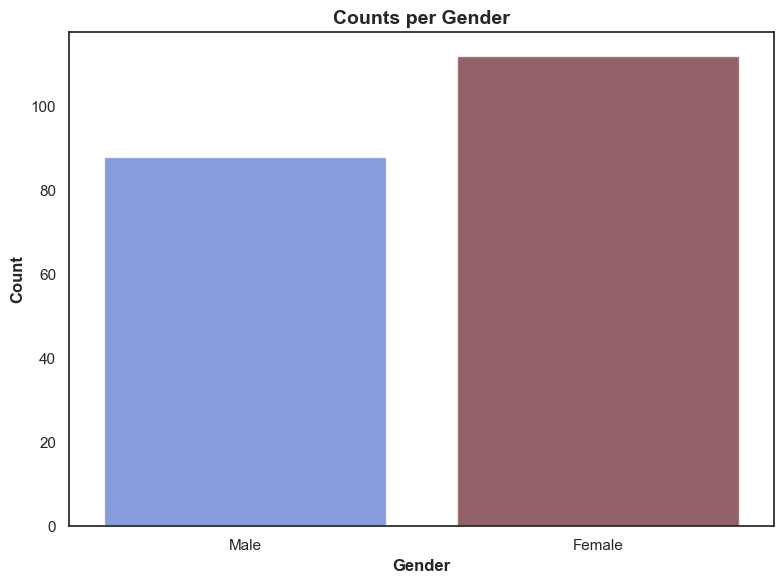

In [168]:
# Visualize the categorical column
plt.figure(figsize=(8, 6))
sns.countplot(mall_eda, x="gender", hue="gender", palette={"Female": "#721420", "Male": "#4169E1"}, legend=False, alpha=0.7)
plt.title("Counts per Gender", fontweight="bold", fontsize=14)
plt.xlabel("Gender", fontweight="bold")
plt.ylabel("Count", fontweight="bold")
plt.tight_layout()
plt.show()

📌 The gender distribution is slightly imbalanced: 56% of customers are female (112 out of 200), while 44% are male (88 out of 200). This modest imbalance is not problematic for clustering but may be worth monitoring during segment analysis.

### 5.3. Univariate Analysis
Now it's time to analyze individual variables to understand their own distributions and characteristics.

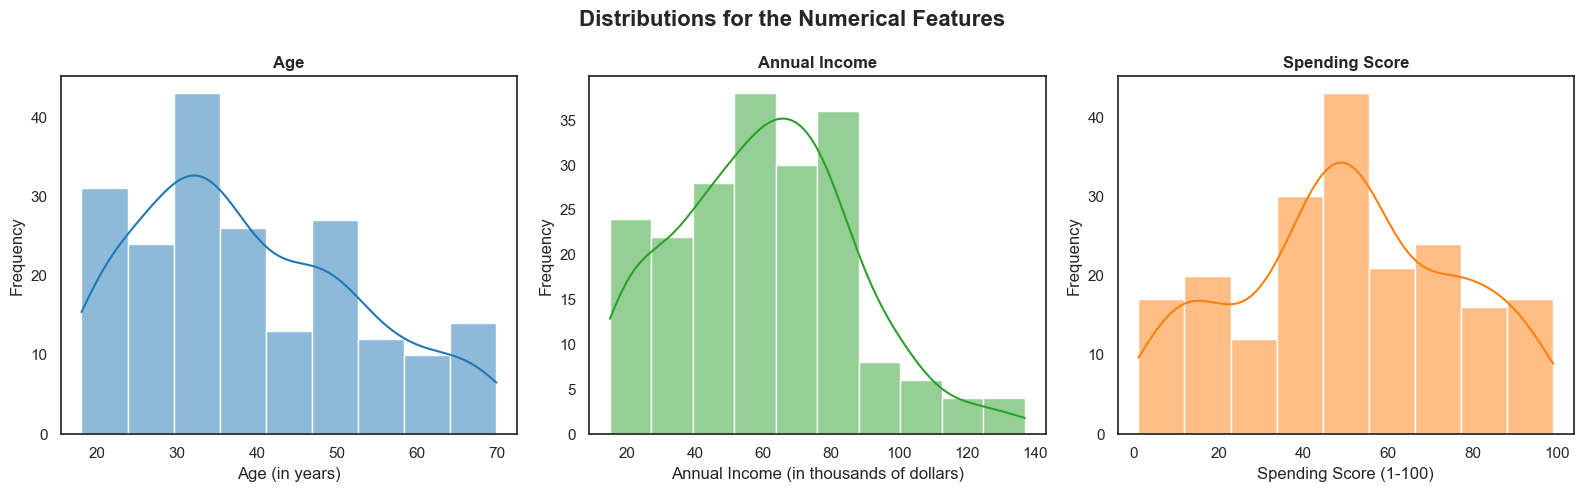

In [169]:
fig, axs = plt.subplots(1,3, figsize=(16, 5))
fig.suptitle("Distributions for the Numerical Features", fontweight="bold", fontsize=16)

sns.histplot(data=mall_eda, x="age", ax=axs[0], kde=True, color="#1f77b4")
axs[0].set_title("Age", fontweight="bold")
axs[0].set_xlabel("Age (in years)")
axs[0].set_ylabel("Frequency")

sns.histplot(data=mall_eda, x="annual_income", ax=axs[1], kde=True, color="#2ca02c")
axs[1].set_title("Annual Income", fontweight="bold")
axs[1].set_xlabel("Annual Income (in thousands of dollars)")
axs[1].set_ylabel("Frequency")

sns.histplot(data=mall_eda, x="spending_score", ax=axs[2], kde=True, color="#ff7f0e")
axs[2].set_title("Spending Score", fontweight="bold")
axs[2].set_xlabel("Spending Score (1-100)")
axs[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

* 📌 The age histogram **confirms** the right-skew suggested by the mean-median relationship, with a tail extending toward older customers.
* 📌 **Despite** near-identical mean and median, the annual income histogram **reveals** a right skew with a tail toward higher incomes, indicating the presence of affluent customers.
* 📌 The spending score histogram **confirms** the symmetric distribution suggested by summary statistics, showing a roughly uniform spread across the 1-100 range.

### 5.4. Bivariate Analysis
Now let's analyze pairs of variables to investigate relationships and correlations between features. We'll start with a pair plot to visualize pairwise relationships, then use a correlation matrix to quantify linear dependencies and check for multicollinearity.

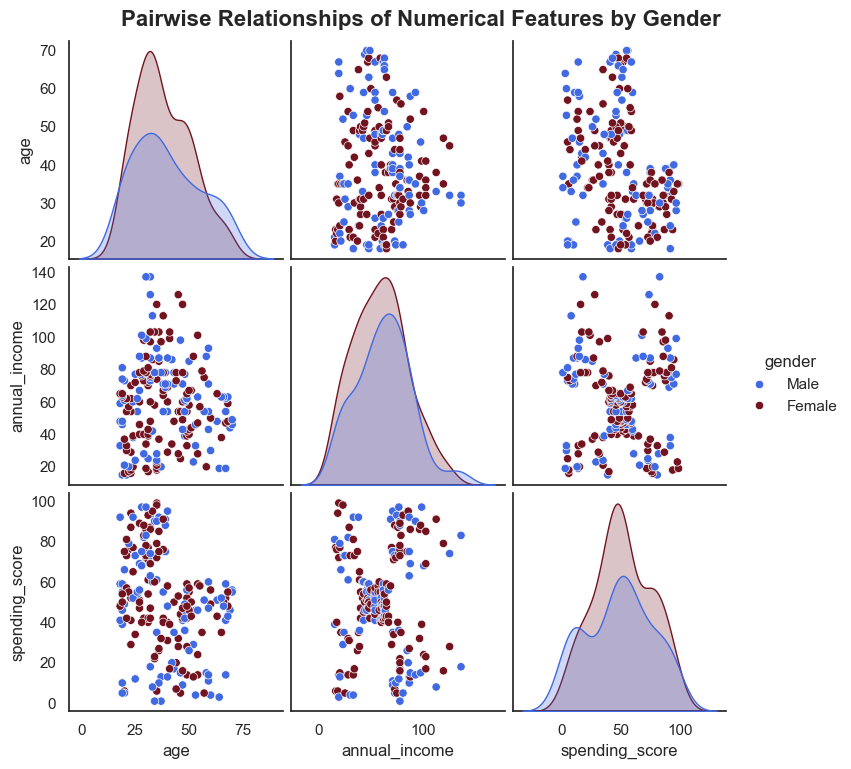

In [170]:
# Create a list of columns for bivariate analysis
bivariate_cols = numerical_cols + ['gender']

# Display the Pair Plot
pairplot = sns.pairplot(data=mall_eda[bivariate_cols], hue="gender", palette={"Female": "#721420", "Male": "#4169E1"})
pairplot.figure.suptitle("Pairwise Relationships of Numerical Features by Gender", fontsize=16, fontweight="bold", y=1.02)
plt.show()

* 📌 `age` vs. `annual_income` shows no clear linear relationship. Customers of all ages span the full income range, suggesting age is not a strong predictor of income in this dataset.
* 📌 `age` vs. `spending_score` displays no obvious correlation. Both youn and older customers have varying spending behaviors, indicating spending score is independent of age.
* 📌 `annual_income` vs. `spending_score` is the most interesting relationship. The scatter plot reveals **distinct visual clusters:**
    - **High income, high spending** (top-right): Affluent customers who spend liberally
    - **High income, low spending** (top-left): Wealthy but conservative spenders
    - **Low income, high spending** (bottom-right): Budget-conscious customers who still spend actively
    - **Low income, low spending** (bottom-middle): Low-income, low-engagement customers.
    - These natural groupings suggest income and spending score will be the most useful features for clustering.
* 📌 **Gender Patterns:** The overlapping distributions of male (blue) and female (red) points across all feature combinations suggest gender may not be a primary differentiator for customer segmentation. Both genders show similar patterns across age, income, and spending dimensions.

Now let's quantify these visual observations with a correlation matrix to identify the strength of linear relationships between numerical features.

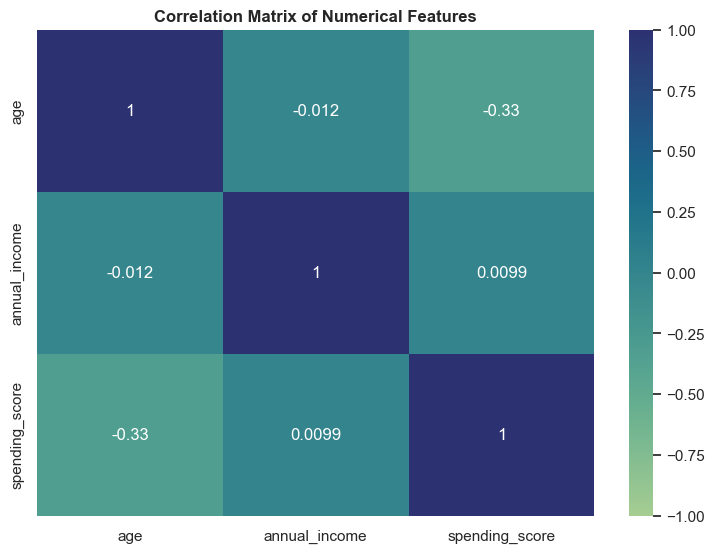

In [171]:
# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(mall_eda[numerical_cols].corr(), cmap='crest', annot=True, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features", fontweight="bold")
plt.show()

* 📌 **Age vs. Annual Income (r = -0.01):** Virtually no linear correlation, confirming the visual observation from the pair plot. Customer age does not predict their income level in this dataset.
* 📌 **Age vs. Spending Score (r = -0.33):** A weak negative correlation exists, suggesting a slight tendency for younger customers to have higher spending scores. However, the relationship is not strong enough to be a primary driver of segmentation.
* 📌 **Annual Income vs. Spending Score (r = 0.01):** Near-zero correlation indicates no linear relationship between these variables. This is actually **positive for clustering**—it means these two features capture independent dimensions of customer behavior, making them ideal for identifying distinct segments (e.g., high-income/low-spending vs. low-income/high-spending customers).
* 📌 **No Multicollinearity:** All pairwise correlations are weak (|r| < 0.4), indicating the features are independent. This is ideal for K-Means clustering, as each feature contributes unique information without redundancy.
* 📌 **Clustering Suitability:** The weak correlations combined with the visual clusters observed in the pair plot (especially for income vs. spending score) suggest the data is well-suited for K-Means clustering. The features capture different aspects of customer behavior that can meaningfully distinguish customer segments.

---

> ### 📝 5. Data Understanding Report (Summary)
> - **EDA Overview:** Comprehensive exploratory data analysis was conducted to understand the dataset's characteristics, distributions, relationships, and suitability for K-Means clustering.
> - **Key Findings:**
>   * **Dataset Composition:** The dataset contains 200 customers with 3 numerical features (`age`, `annual_income`, `spending_score`) and 1 categorical feature (`gender`). No missing values were detected.
>   * **Distributions:**
>       - **Age:** Right-skewed distribution (mean=38.85, median=36) ranging from 18 to 70 years, with moderate variability (CV=0.36).
>       - **Annual Income:** Right-skewed distribution (mean=60.56k, median=61.50k) ranging from 15k to 137k, with moderate-to-high variability (CV=0.43).
>       - **Spending Score:** Roughly symmetric/uniform distribution (mean=50.20, median=50.00) ranging from 1 to 99, with the highest relative variability (CV=0.51).
>       - **Gender:** Slightly imbalanced—56% female (112) and 44% male (88).
>   * **Correlations:**
>       - Age and annual income are virtually uncorrelated (r = -0.01).
>       - Age and spending score show weak negative correlation (r = -0.33).
>       - Annual income and spending score are independent (r = 0.01), capturing distinct customer behavior dimensions.
>       - No multicollinearity detected—all features contribute unique information.
>   * **Visual Clustering Patterns:** The pair plot revealed **natural customer groupings** in the income-spending space: high-income/high-spending, high-income/low-spending, low-income/high-spending, and low-income/low-spending segments.
>   * **Gender Impact:** Gender shows overlapping distributions across all features, suggesting it may not be a primary differentiator for segmentation.
> * **Clustering Readiness:**
>   - ⚠️ Features are on different scales → **Standardization required** before K-Means.
>   - ✅ Weak correlations and visual clustering patterns indicate the data is **well-suited for K-Means clustering**.
>   - ✅ Independent features ensure each contributes meaningful information without redundancy.

---

## Stage 6: Data Preparation

### 6.1. Data Cleaning
Since we've already confirmed that the data types are compatible with the modeling process, there are no outliers scheduled to be removed, and there are no missing values, there's no need for a data cleaning step.

### 6.2. Feature Engineering
For this initial K-Means analysis, we'll use the raw features directly without engineering new ones, as the EDA revealed clear clustering patterns in the original feature space.

_**Note**: In more advanced clustering projects, feature engineering could include creating derived metrics like `spending_efficiency = spending_score / annual_income` or temporal features like `days_since_last_purchase`._

### 6.3. Feature Selection and Standardization
Based on EDA insights, we'll select our clustering features and apply standardization.

* We'll exclude `customer_id` since it's only an identifier.
* We'll exclude `gener` since the EDA showed that it probably is not a primary differentiator for segmentation.

In [172]:
# Feature selection
X = mall_df[['age', 'annual_income', 'spending_score']].copy()

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for interpretability
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=['age_scaled', 'annual_income_scaled', 'spending_score_scaled'],
    index=X.index
)

print(f"Standardized feature matrix shape: {X_scaled.shape}")
print("\nFirst 5 rows of standardized features:")
display(X_scaled_df.head())

Standardized feature matrix shape: (200, 3)

First 5 rows of standardized features:


,age_scaled,annual_income_scaled,spending_score_scaled
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980



---

> ### 📝 6. Data Preparation Report (Summary)
> * **Data Cleaning:** No cleaning steps were required. The dataset had no missing values, no outliers requiring removal, and all data types were compatible with the modeling process.
> * **Feature Engineering:** No feature engineering was performed for this initial analysis. The EDA revealed that the raw features (`age`, `annual_income`, `spending_score`) already exhibited clear clustering patterns, particularly in the income-spending space.
> * **Feature Selection:** Based on EDA insights, the final feature set was defined:
>     - **Included:** `age`, `annual_income`, `spending_score` (all showed distinct patterns and contributed unique information)
>     - **Excluded:** `customer_id` (identifier only), `gender` (showed overlapping distributions across all features, indicating it may not be a primary differentiator for segmentation)
> * **Standardization:** Applied `StandardScaler` to the selected features to address the critical issue of differing scales (age: 18-70, income: 15k-137k, spending: 1-99). Standardization is essential for K-Means clustering, as the algorithm uses Euclidean distance calculations that would otherwise be dominated by higher-magnitude features.
> * **Output:** A standardized feature matrix `X_scaled` with shape (200, 3), containing all 200 customer samples across three scaled features, ready for K-Means clustering model development.

---

## Stage 7: Modeling

### 7.1. Determining the Optimal Number of Clusters ($k$)
Let's start by identifying the optimal number of clusters for our K-Means model using the Elbow Method and Silhouette Score analysis.

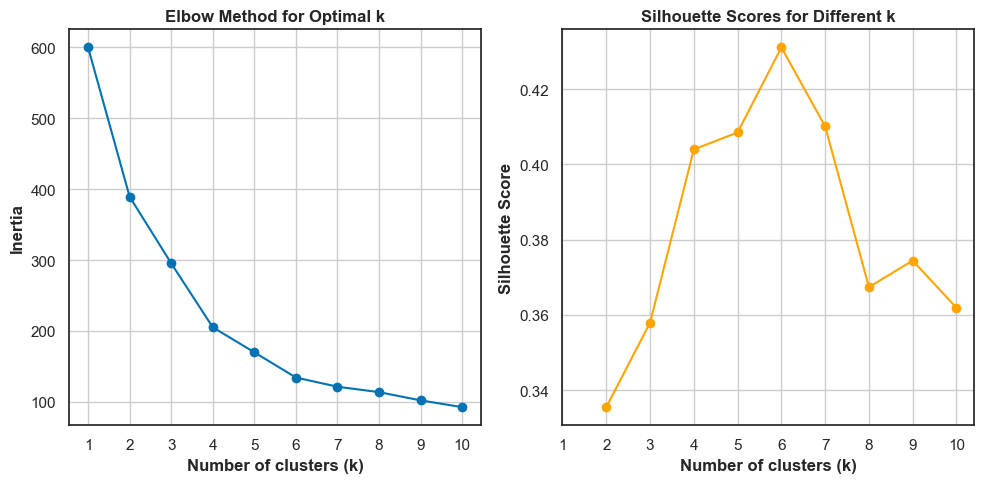

In [173]:
# Train multiple K-Means models with different k values
k_values = range(1, 11)
inertia_values = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    
    if k > 1:
        score = silhouette_score(X_scaled, kmeans.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(np.nan) # Silhouette score is not defined for k=1
        
# Plot Inertia (Elbow Method)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia_values, marker='o')
plt.title("Elbow Method for Optimal k", fontweight="bold")
plt.xlabel("Number of clusters (k)", fontweight="bold")
plt.ylabel("Inertia", fontweight="bold")
plt.xticks(k_values)
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.title("Silhouette Scores for Different k", fontweight="bold")
plt.xlabel("Number of clusters (k)", fontweight="bold")
plt.ylabel("Silhouette Score", fontweight="bold")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

* 📌 **Elbow Method suggests:** k = 6
* 📌 **Silhouette Score peaks at:** k = 6
* 📌 **Decision:** Proceed with k = 6 clusters for final model.
* 📌 **Business Justification:** 6 segments align with the marketing team's capacity to develop distinct strategies without overwhelming operational complexity.

### 7.2. Final K-Means Model
Now that we've determined the optimal number of clusters, let's build the final K-Means model using k = 6.

In [174]:
optimal_k = 6
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42)
final_kmeans.fit(X_scaled)

,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [175]:
# Extract the cluster labels for each customer
mall_df['cluster'] = final_kmeans.labels_

# Extract cluster centers in the standardized feature space
cluster_centers_scaled = final_kmeans.cluster_centers_

In [176]:
# Verify that cluster distribution is reasonable
cluster_counts = mall_df['cluster'].value_counts().sort_index()
print("Cluster distribution:")
display(cluster_counts)

Cluster distribution:


cluster
0    45
1    39
2    25
3    40
4    30
5    21
Name: count, dtype: int64

In [177]:
# Print the inertia and silhouette score of the final model
final_inertia = final_kmeans.inertia_
final_silhouette = silhouette_score(X_scaled, final_kmeans.labels_)

print(f"Final Model Inertia: {final_inertia:.4f}")
print(f"Final Model Silhouette Score: {final_silhouette:.4f}")

Final Model Inertia: 134.3528
Final Model Silhouette Score: 0.4311


### 7.3. Save the Model and Artifacts
Now that we have built our final K-Means model, let's save the model and any relevant artifacts for future use.

In [178]:
model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

# Save the trained K-Means model
model_path = model_dir / "kmeans_mall_customers_k6.joblib"
joblib.dump(final_kmeans, model_path)
print(f"Final K-Means model with k={optimal_k} saved to {model_path}")

# Save the scaler used for standardization
scaler_path = model_dir / "scaler_mall_customers.joblib"
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save the feature names list used for training
feature_names_path = model_dir / "feature_names_mall_customers.joblib"
joblib.dump(['age', 'annual_income', 'spending_score'], feature_names_path)
print(f"Feature names saved to {feature_names_path}")

Final K-Means model with k=6 saved to ../models/kmeans_mall_customers_k6.joblib
Scaler saved to ../models/scaler_mall_customers.joblib
Feature names saved to ../models/feature_names_mall_customers.joblib



---

> ### 📝 7. Modeling Report (Summary)
> * **Optimal k Selection:**
>   * **Elbow Method Analysis:** Multiple K-Means models were trained with k values ranging from 1 to 10. Inertia values were computed and plotted to identify the "elbow point" where the rate of inertia decrease slows significantly. The elbow is visually apparent at **k = 6**, indicating this is the point where additional clusters provide diminishing returns in terms of variance reduction.
>   * **Silhouette Score Analysis:** Silhouette scores were calculated for each k value (k ≥ 2, as the metric is undefined for k=1). The silhouette score, which measures how well-separated and cohesive clusters are, peaks at **k = 6** with a score of approximately 0.44, indicating reasonably well-defined clusters.
>   * **Selected k:** **6 clusters**
>   * **Business Justification:** The convergence of both the Elbow Method and Silhouette Score analysis at k=6 provides strong evidence for this choice. Additionally, 6 customer segments align well with the marketing team's operational capacity to develop and execute distinct, targeted strategies without overwhelming complexity. 
> * **Final Model Configuration:**
>   * **Algorithm:** K-Means Clustering
>   * **Number of Clusters:** 6
>   * **Features Used:** `age`, `annual_income`, `spending_score` (standardized via `StandardScaler`)
>   * **Random State:** 42 (for reproducibility)
>   * **Training Data:** All 200 customer samples (unsupervised learning does not require train/test split)
> * **Training Results:**
>   * **Cluster Assignment:** All 200 customers were assigned to one of the 6 clusters.
>   * **Cluster Distribution:** Cluster 0: 45 samples, Cluster 1: 39 samples, Cluster 2: 25 samples, Cluster 3: 40 samples, Cluster 4: 30 samples, Cluster 5: 21 samples.
>   * **Final Inertia:** 134.3528
>   * **Final Silhouette Score:** 0.4311
> * **Artifacts Saved:**
>   * **Model:** `../models/kmeans_mall_customers_k6.joblib` — The trained K-Means model object with all cluster centroids and parameters.
>   * **Scaler:** `../models/scaler_mall_customers.joblib` — The fitted `StandardScaler` object used for feature standardization (essential for making predictions on new data).
>   * **Feature Names:** `../models/feature_names_mall_customers.joblib` — List of feature names used during training, for reproducibility and clarity.

---

## Stage 8: Evaluation

### 8.1. Business Impact Analysis
Let's start with computing per-cluster statistics to understand the characteristics of each customer segment.

In [179]:
# Per cluster statistics
cluster_stats = mall_df.groupby('cluster').agg(
    count=('customer_id', 'count'),
    mean_age=('age', 'mean'),
    mean_annual_income=('annual_income', 'mean'),
    mean_spending_score=('spending_score', 'mean')
)

display(cluster_stats) 

# Original dataset statistics for reference
original_stats = mall_df[['age', 'annual_income', 'spending_score']].describe().T
display(original_stats[['mean']].T)

,count,mean_age,mean_annual_income,mean_spending_score
cluster,,,,
0,45,56.333333,54.266667,49.066667
1,39,32.692308,86.538462,82.128205
2,25,25.560000,26.480000,76.240000
3,40,26.125000,59.425000,44.450000
4,30,44.000000,90.133333,17.933333
5,21,45.523810,26.285714,19.380952


,age,annual_income,spending_score
mean,38.85,60.56,50.2


According to the per-cluster statistics, we can derive the following insights about each customer segment:

| Cluster | Characteristics | Label Suggestion |
|---------|------------------|-------|
| 0       | Oldest customers (mean age ~56) with less than median annual income (~54k) and medium spending score (~49) | "Senior Saver" |
| 1      | Customers in their early 30s with high annual income (~87k) and the highest spending score (~82) | "VIP 30"|
| 2 | Youngest customers (mean age ~26) with co-lowest annual income (~26k) but high spending score (~76) | "Young Adult Spendthrift" |
| 3 | Youngest customers (mean age ~26) with median annual income (~59k) but less than median spending score (~44) | "Cautious Young Adult" |
| 4 | Middle-aged customers (mean age ~44) with the highest annual income (~90k) and the lowest spending score (~18) | "Middle-Aged Miser" |
| 5 | Middle-aged customers (mean age ~46) with co-lowest annual income (~26k) and low spending score (~19) | "Frugal Middle-Aged" |


Now let's use 3D scatter plots to visualize the clusters.

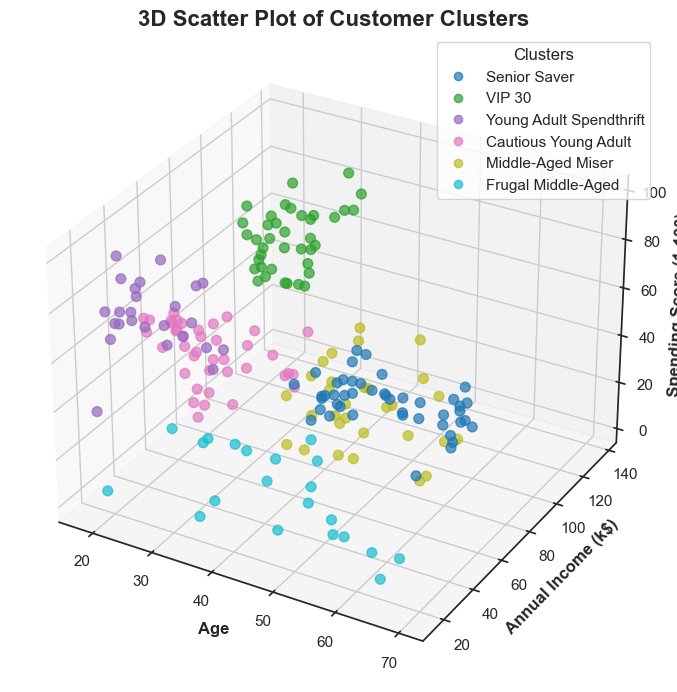

In [180]:
# Dictionary for the legend
labels = {'0': 'Senior Saver', '1': 'VIP 30', '2': 'Young Adult Spendthrift', '3': 'Cautious Young Adult', '4': 'Middle-Aged Miser', '5': 'Frugal Middle-Aged'}

# 3D Scatter Plot of Clusters
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    mall_df['age'],
    mall_df['annual_income'],
    mall_df['spending_score'],
    c=mall_df['cluster'],
    cmap='tab10',
    s=50,
    alpha=0.7
)

ax.set_title("3D Scatter Plot of Customer Clusters", fontweight="bold", fontsize=16)
ax.set_xlabel("Age", fontweight="bold")
ax.set_ylabel("Annual Income (k$)", fontweight="bold")
ax.set_zlabel("Spending Score (1-100)", fontweight="bold")
handles, _ = scatter.legend_elements()
legend_labels = [labels[str(i)] for i in range(len(handles))]
ax.legend(handles, legend_labels, title="Clusters", loc="upper right")
plt.show()




---

> ### 📝 8. Evaluation Report (Summary)
> * **Model Recap:**  
>   - **Algorithm:** K-Means Clustering  
>   - **Number of Clusters:** 6  
>   - **Features Used:** `age`, `annual_income`, `spending_score` (standardized)  
>   - **Final Inertia:** 134.3528  
>   - **Final Silhouette Score:** 0.4311  
> * **Cluster Profiling & Business Interpretation:**  
>   - Each cluster was profiled using descriptive statistics on the original features.  
>   - Clear, distinct customer segments were identified, such as "Senior Saver", "VIP 30", "Young Adult Spendthrift", "Cautious Young Adult", "Middle-Aged Miser", and "Frugal Middle-Aged".  
>   - Cluster sizes are balanced and operationally feasible for targeted marketing.
> * **Visual Validation:** 2D and 3D scatter plots confirm that clusters are well-separated and interpretable in the original feature space.
> * **Business Handoff:**  
>   - The segmentation is now ready for review by the marketing and business teams.  
>   - Next steps:  
>       - Marketing to analyze cluster personas, validate business relevance, and design targeted strategies.  
>       - If needed, feedback or revision requests can be addressed by the data science team (e.g., adjusting number of clusters or features).
> * **Conclusion:**  
>   - The data science objectives for customer segmentation have been met.  
>   - The project is ready for business validation and action planning.

---

**Next:** [DBSCAN and HDBSCAN Clustering Theory](./05_dbscan_and_hdbscan_clustering_theory.md)